# Training of an XQNN model
Compatible with Qiskit 1.2.4+

### Author
- Jacob L. Cybulski, Enquanted

### Date
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, <br/>
  organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation.<br/>
  In assoc. with IEEE Conf Trends in Quantum Computing and Emerging Business Technologies TQCEBT'2022
- May 2024: Compatibility upgrade to Qiskit 1.2.4+
- Feb 2025: Addition of model instances

### Aims
> *This script aims to fit time series data with quantum neural network.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

### Primary Sources
- Schreiber, Amelie. “Quantum Neural Networks for FinTech.” 
    Medium, May 8, 2020.<br/> 
    https://towardsdatascience.com/quantum-neural-networks-for-fintech-dddc6ac68dbf
- Qiskit Team. "Tutorial: Neural Network Classifier & Regressor", Last updated: 31 Aug 2022.<br/>
    https://qiskit.org/documentation/machine-learning/tutorials/02_neural_network_classifier_and_regressor.html

In [1]:
import sys
sys.path.append('.')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.']

In [2]:
import os
import numpy as np
import pylab
import math
import json
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Target import *
from utils.Window import *
from utils.TS import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Libraries used in QTSA development

from IPython.display import clear_output
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit
from qiskit_algorithms.optimizers import L_BFGS_B, P_BFGS, COBYLA, NELDER_MEAD, QNSPSA, ADAM, UMDA
from qiskit_algorithms.optimizers import SPSA
from qiskit.circuit.library import RealAmplitudes, TwoLocal, ZFeatureMap, ZZFeatureMap,EfficientSU2, PauliFeatureMap
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_algorithms.utils import algorithm_globals
from qiskit.visualization import plot_histogram, plot_state_city, plot_state_paulivec
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.utils.loss_functions import L1Loss, L2Loss
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit_machine_learning.gradients import LinCombEstimatorGradient, DerivativeType
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile

from sklearn.metrics import r2_score, mean_absolute_percentage_error 

In [4]:
### Listing control
debug = True

### Software version
MAJOR = 9
MINOR = 12

### Constants
LOG_NAME = 'log_4_iter'
CASE_NAME = 'xqnn_ng'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('log_4_iter',
 'xqnn_ng',
 '2_sins_sw',
 'log_4_iter/data',
 'log_4_iter/training',
 'log_4_iter/analysis',
 'log_4_iter/figures')

## Utils

In [5]:
def rand_seed():
    t=time.time(); t = int((t-int(t))*10000)
    return t

## Fetch data

In [6]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [7]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [8]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



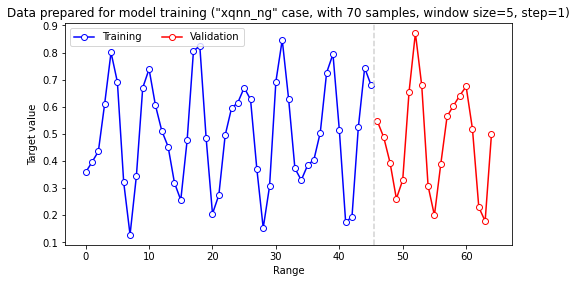

In [9]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['blue', 'red'], marker_colors=['white', 'white', 'lightblue', 'mistyrose'],
    labels = ['Training', 'Validation'], #ylim=(0.1, 1),
    lines = ['solid', 'solid'], markers = ['o', 'o'], legend_cols=2,
    title=f'Data prepared for model training ("{CASE_NAME}" case, with {samples} samples, window size={wind_size}, step={wind_step})')
print()

## Quantum Neural Network model

### Identify device

In [10]:
##### Find what devices are available
from qiskit_aer import Aer
from qiskit_aer.backends import AerSimulator
devices = AerSimulator().available_devices()
print(f'Available devices:\t{devices}')

### Priority GPU
device = 'GPU' if ('GPU' in devices) else 'CPU'

### Force CPU for this run
device = 'CPU'
print(f'Selected device:\t{device}')

Available devices:	('CPU', 'GPU')
Selected device:	CPU


In [11]:
from qiskit.primitives import Sampler, Estimator # For "CPU", ignores device="GPU" option
from qiskit_aer.primitives import Sampler as AerSampler, Estimator as AerEstimator # For device="GPU" option

seed = 2022
shots = 10000

if device == 'GPU':
    sampler = AerSampler(
        backend_options={'seed_simulator': seed, 'method': 'statevector', 
                         'device' : device, 'cuStateVec_enable' : True},
        run_options={'seed': seed, 'shots': shots},
        transpile_options={'seed_transpiler': seed},
    )
    
    estimator = AerEstimator(
        backend_options={'seed_simulator': seed, 'method': 'statevector', 
                         'device' : device, 'cuStateVec_enable' : True},
        run_options={'seed': seed, 'shots': shots},
        transpile_options={'seed_transpiler': seed},
    )
else:
    sampler = Sampler()
    estimator = Estimator()

### QNN circuit ansatz - sample


Example: Inputs#=5, Qubits#=5, Weight params#=90, FM Layer#=1, ANZ Layer#=5




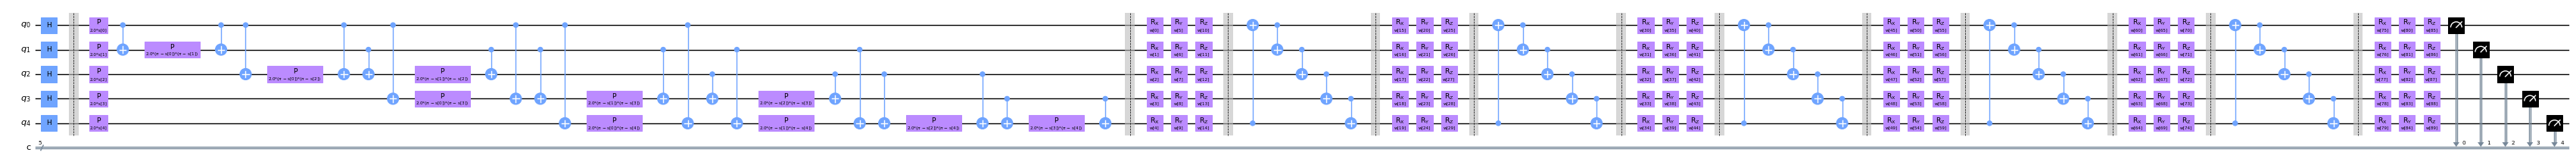

In [12]:
# Test a sample QNN model
test_qubits = 5; test_inputs= 5; test_fm_layers = 1; test_anz_layers = 5; test_ent = 'circular'
test_m, test_input_params, test_weight_params = \
    swindow_qnn_model(test_qubits, test_inputs, test_fm_layers, test_anz_layers, ent=test_ent, add_meas=True)

# print(f'QNN Params: {m.parameters}\n')
# print(f'Input params:\n{input_params}')
# print(f'\nWeight params:\n{weight_params}')
print(f'\nExample: Inputs#={len(test_input_params)}, Qubits#={test_qubits}, Weight params#={len(test_weight_params)}, FM Layer#={test_fm_layers}, ANZ Layer#={test_anz_layers}')

print()
test_m.draw(output='mpl', style='clifford', fold=False, scale=0.7)
print()

## Create the model template

In [13]:
# Define model parameters and their initial values (including random input)

inst_no = 10
epochs = 60 # 80
log_interval = 1
prompt_interval = 1
qubits = 5
inputs = X_train_ts.shape[1] # wind_size
fm_layers = 1
anz_layers = 5
ent = 'circular'

# Define constants for each iteration
if seed == 0: 
    np.random.seed(rand_seed())
else:
    np.random.seed(seed)
inst_seeds = [int(n) for n in np.random.randint(0, high=9999, size=inst_no)]

In [14]:
# Recommended optimizers and their parameters:  
#   COBYLA() # COBYLA(maxiter=300) # COBYLA(maxiter=500) - very fast
#   NELDER_MEAD() # NELDER_MEAD(maxiter=100) # NELDER_MEAD(maxiter=500) - slower
#   L_BFGS_B() # L_BFGS_B(maxiter=10) # L_BFGS_B(maxiter=16)
#   SPSA(maxiter=5000)
# Not recommended: 
#   ADAM(maxiter=100) - never comes back / callbacks still do not work
#   UMDA(maxiter=200) - slow/incorrect callbacks

In [15]:
### Run definition

# Define output interpretations (sampler)
output_shape = 2
parity = lambda x: "{:b}".format(x).count("1") % 2
first_only = lambda x: x % 2
identity_interpret = lambda x: x

# Define observables (estimator)
op = SparsePauliOp.from_list([("Z" * qubits, 1)]) 
op1 = SparsePauliOp.from_list([("I" * qubits, 0.5), ("Z" * qubits, 0.5)])
op2 = SparsePauliOp.from_list([("I" * qubits, 0.5), ("Z" * qubits, -0.5)])

# Create a sample model to find its features
sample_model, input_params, weight_params = \
    swindow_qnn_model(qubits, inputs, fm_layers, anz_layers, ent=ent)
sample_optimizer = L_BFGS_B(maxiter=epochs)

# Run specs
print(f'\n'+
      f'Run details:\t'+
      f'device = {device}, '+
      f'samples = {y_train_ts.shape[0]}, '+
      f'features = {X_train_ts.shape[1]}\n\t\t'+
      f'qubits = {qubits}, '+
      f'fm_layers = {fm_layers}, '+
      f'anz_layers = {anz_layers}, '+
      f'ent = {ent}\n\t\t'+
      f'input params = {len(input_params)}, '+
      f'weight params = {len(weight_params)}\n\t\t'+
      f'inst no = {inst_no}, '+
      f'epochs = {epochs}'+
      f'\n'
     )


Run details:	device = CPU, samples = 46, features = 5
		qubits = 5, fm_layers = 1, anz_layers = 5, ent = circular
		input params = 5, weight params = 90
		inst no = 10, epochs = 60



In [16]:
### Training parameters

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   fm: number of fm layers
#   anz: number of ansatz layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs
opt_name = sample_optimizer.setting.splitlines()[0][11:]
TRAIN_PREF = f'{DATA_NAME}_{CASE_NAME}_n{samples}_z{noise}_q{qubits}_in{inputs}_fm{fm_layers}_anz{anz_layers}_'+\
             f'{opt_name}_ep{epochs}'
TRAIN_PREF

'2_sins_sw_xqnn_ng_n70_z0_q5_in5_fm1_anz5_L_BFGS_B_ep60'

In [17]:
### Save info details
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/info.json'
train_info = \
    {'case_name':CASE_NAME, 
     'major_version':MAJOR, 
     'minor_version':MINOR,
     'data_name':DATA_NAME,
     'data_sample':samples,
     'data_split':train_pc,
     'data_noise':noise,
     'ansatz_qubits':qubits,
     'ansatz_inputs':inputs,
     'ansatz_fm_layers':fm_layers,
     'ansatz_anz_layers':anz_layers,
     'ansatz_ent':ent,
     'log_interv':1,
     'opt_name':opt_name,
     'epochs':epochs,
     'shots':shots,
     'seed':seed,
     'inst_no':inst_no,
     'inst_seeds':inst_seeds,
    }

### Saving the info file
write_json_file(train_info_fpath, train_info)
    
print(f'\nSaved time series info in file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
print()


Saved time series info in file "log_4_iter/training/2_sins_sw_xqnn_ng_n70_z0_q5_in5_fm1_anz5_L_BFGS_B_ep60/info.json":

	info[case_name] = xqnn_ng
	info[major_version] = 9
	info[minor_version] = 12
	info[data_name] = 2_sins_sw
	info[data_sample] = 70
	info[data_split] = 0.7142857142857143
	info[data_noise] = 0
	info[ansatz_qubits] = 5
	info[ansatz_inputs] = 5
	info[ansatz_fm_layers] = 1
	info[ansatz_anz_layers] = 5
	info[ansatz_ent] = circular
	info[log_interv] = 1
	info[opt_name] = L_BFGS_B
	info[epochs] = 60
	info[shots] = 10000
	info[seed] = 2022
	info[inst_no] = 10
	info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Train the model instances

In [18]:
### Define instance list to create
inst_list = list(range(inst_no))
# inst_list = [0, 1, 2, 3, 4, 5]

### Observe progress here
progress_bar = tqdm(total=int(epochs*len(inst_list)*1.25), desc='XQNN training progress: : ')

XQNN training progress: :   0%|          | 0/750 [00:00<?, ?it/s]

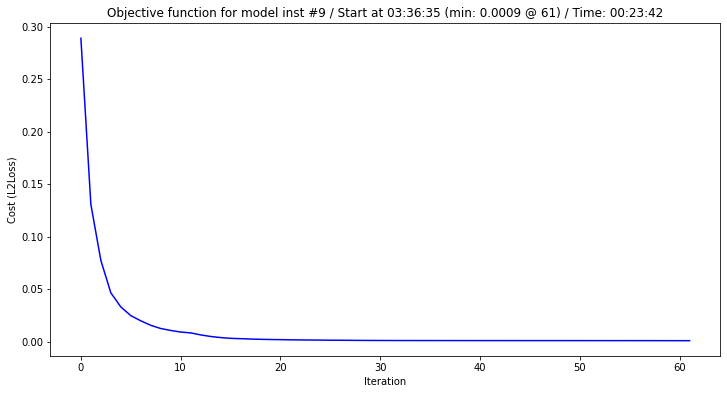


Completed 10 model instances @ Total time 04:00:40


In [19]:
##### Iterate through model creation

objfun_vals_list = []
start = time.time()
elapsed = time.time() - start
time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))

for inst in inst_list:

    ### Start a new instance training
    print(f'\nModel instance: {inst}\n')

    ### Start a random process
    algorithm_globals.random_seed = inst_seeds[inst]
    np.random.seed(inst_seeds[inst])
    
    ### Create a model
    model, input_params, weight_params = \
        swindow_qnn_model(qubits, inputs, fm_layers, anz_layers, ent=ent)
    init_weights = 2 * np.pi * algorithm_globals.random.random(model.num_parameters-inputs)
    
    ### Prepare gradients and a pass manager
    # pm = generate_preset_pass_manager(backend=sim, optimization_level=1)
    # pm_model = pm.run(model)
    
    # gradient = LinCombEstimatorGradient(estimator)
    # gradient = ParamShiftEstimatorGradient(estimator)
    # gradient = SPSAEstimatorGradient(estimator)
    
    ### Construct QNN
    regr_qnn = EstimatorQNN(
        # circuit=pm_model,
        circuit=model,
        input_params=model.parameters[:inputs],
        weight_params=model.parameters[inputs:],
        observables=op,
        estimator=estimator,
        # gradient=gradient,
    )
    
    ### Define loss function and a regressor
    loss_fun = L2Loss()
    loss_fun_name = 'L2Loss'
    
    # optimizer = ADAM(maxiter=epochs, amsgrad=True)
    # optimizer = SPSA(maxiter=epochs, learning_rate=0.01, perturbation=0.05, last_avg=log_interval)
    # optimizer = COBYLA(maxiter=epochs)
    optimizer = L_BFGS_B(maxiter=epochs)
    
    regr_callback = Regr_callback(tqdm_progress=progress_bar, 
        log_interval=log_interval, prompt_interval=prompt_interval,
        title=f'Objective function for model inst #{inst} / Start at {time_str}', 
        ylabel=f'Cost ({loss_fun_name})')
    
    regressor = NeuralNetworkRegressor(
        neural_network=regr_qnn,
        loss=loss_fun,
        optimizer=optimizer, 
        initial_point=init_weights, 
        callback=regr_callback.objfun_graph
        # callback=regr_callback.objfun_print
    )

    ### Train the model

    # Initiate model training
    regr_callback.reset()
    
    # fit regressor
    regressor.fit(X_train_ts, np.array([y[0] for y in y_train_ts])) 
    elapsed = time.time() - start
    time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
    
    ### Get the results
    params_vals = np.array(regr_callback.params_vals)
    objfun_vals = np.array(regr_callback.objfun_vals)

    ### Save the current model results info the log 
    init_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/init.arr'
    history_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/hist.arr'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/params.arr'
    write_ts_file(init_fpath, init_weights)
    write_ts_file(history_fpath, objfun_vals)
    write_ts_file(params_fpath, params_vals)
    objfun_vals_list.append(copy.deepcopy(objfun_vals))

### Total time  
print(f'\nCompleted {len(inst_list)} model instances @ Total time {time_str}')

## Report training performance

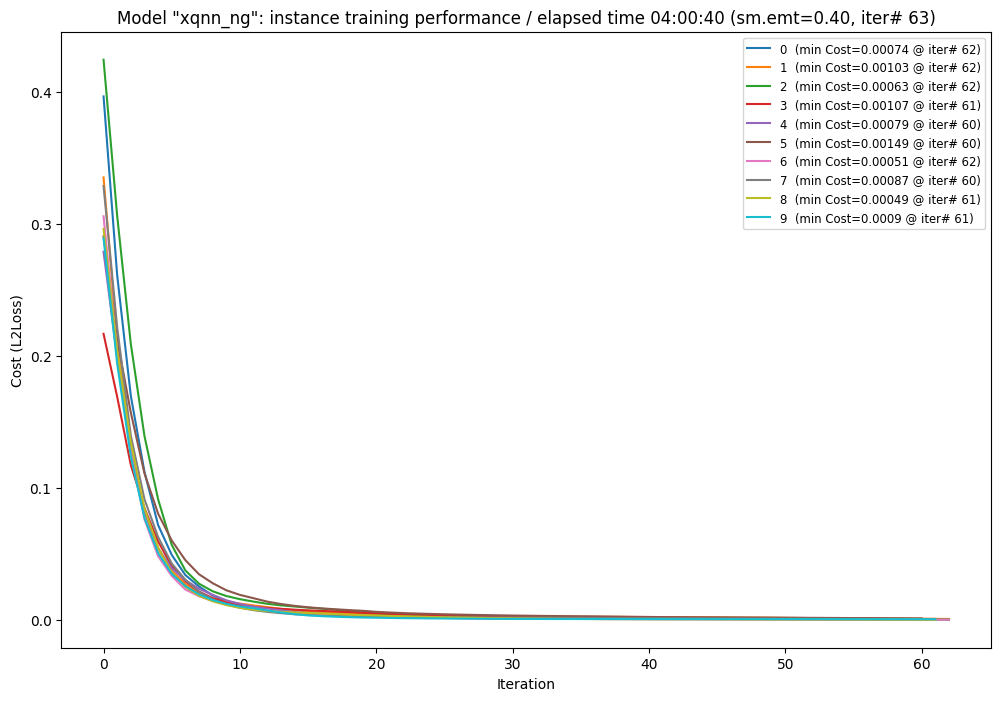

In [20]:
### Plot all trained instances
lin_plot_path = f'{FIGURES_PATH}/{TRAIN_PREF}/train_perform_vs_iter_lin_'+'_'.join(f'{x:02d}' for x in inst_list)+'.eps'
multi_perform_plot(objfun_vals_list, log_interv=log_interval, smooth_weight=0.4, 
                   rcParams=(12, 8), dpi=100, meas_type=f'Cost', ylabel=f'Cost ({loss_fun_name})',
                   title=f'Model "{CASE_NAME}": instance training performance / elapsed time {time_str}', 
                   labels=inst_list, save_plot=lin_plot_path
                   )

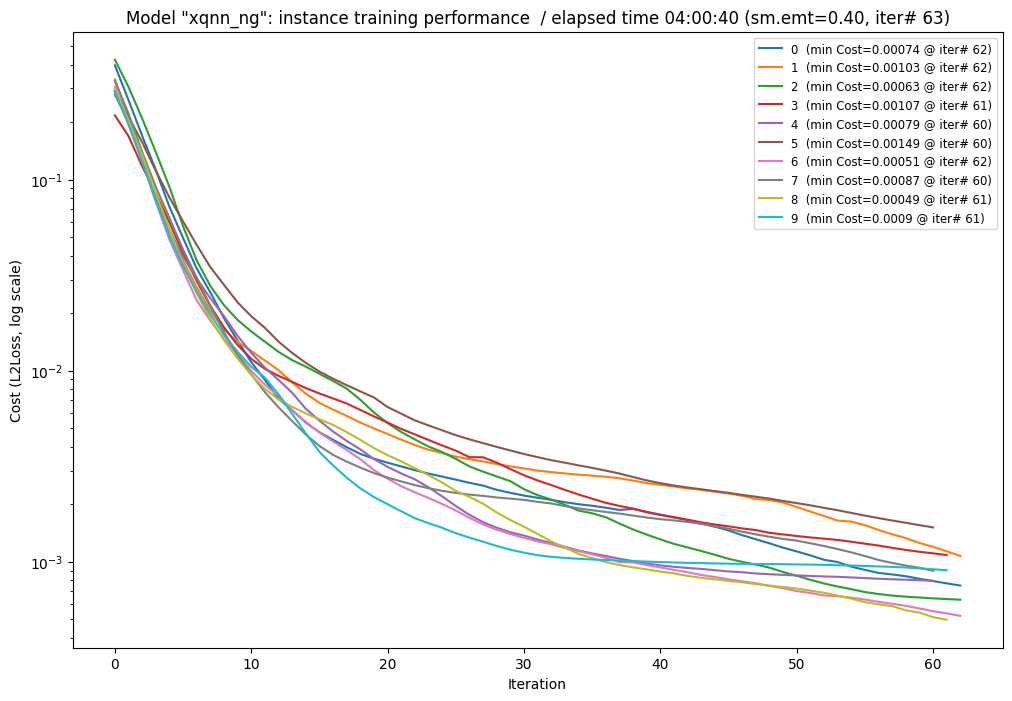

In [21]:
### Plot all trained instances
log_plot_path = f'{FIGURES_PATH}/{TRAIN_PREF}/train_perform_vs_iter_log_'+'_'.join(f'{x:02d}' for x in inst_list)+'.eps'
multi_perform_plot(objfun_vals_list, log_interv=log_interval, smooth_weight=0.4, 
                   rcParams=(12, 8), dpi=100, yscale='log', ylabel=f'Cost ({loss_fun_name}, log scale)',
                   title=f'Model "{CASE_NAME}": instance training performance  / elapsed time {time_str}', 
                   labels=inst_list, save_plot=log_plot_path
                   )

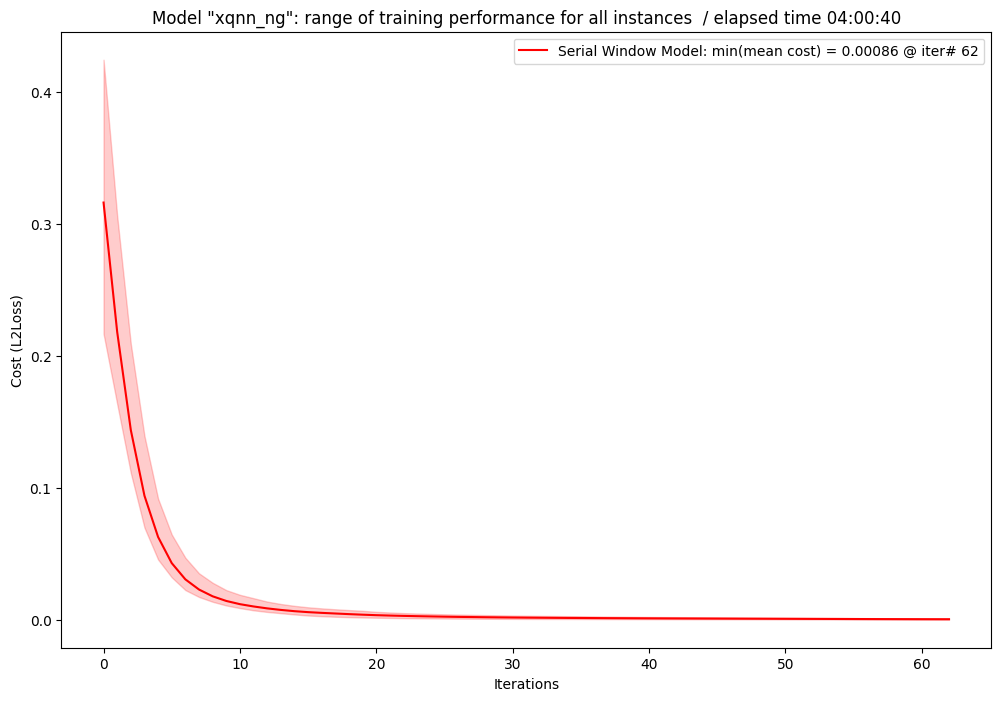

In [22]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
range_plot_path = f'{FIGURES_PATH}/{TRAIN_PREF}/train_perform_vs_iter_range_'+'_'.join(f'{x:02d}' for x in inst_list)+'.png'
plot_objfn_range([objfun_vals_list], smooth_weight=0.4, log_interv=log_interval, ylabel=f'Cost ({loss_fun_name})', 
                 title=f'Model "{CASE_NAME}": range of training performance for all instances  / elapsed time {time_str}', 
                 objfn_list=['Serial Window Model'], rcParams=(12, 8), dpi=100, save_plot=range_plot_path
                 ) # , objfn_name=None)

## System

In [23]:
!lsb_release -d

Description:	Ubuntu 22.04.5 LTS


In [24]:
!python --version

Python 3.11.11


In [25]:
import sys
print(f'\nEnvironment:\n\n{sys.prefix}\n')


Environment:

/home/jacob/miniconda3/envs/qiskit-gpu



In [26]:
import os
print(f"\nSignificant packages:\n")
os.system('pip list | grep -e qiskit');


Significant packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
